# Set-up

In [128]:
import os
import sys
import glob
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import numpy as np
import pandas as pd

from PyComplexHeatmap import *
import seaborn as sns

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['pdf.fonttype'] = 42

In [1]:
results_dir = "/cellar/users/aklie/projects/igvf/topic_grn_links/eval/results"
dataset_name = "meta_analysis"
in_date = "03Sep23"

In [110]:
# Get colors in "Set2" palette
colors = 
colors

'#ccebc5'

In [129]:
method = "Set2"
dataset = "Dark2" # first and fourth
normalization = "Paired" #every other

In [136]:
sns.color_palette("Paired").as_hex()[:]

['#a6cee3',
 '#1f78b4',
 '#b2df8a',
 '#33a02c',
 '#fb9a99',
 '#e31a1c',
 '#fdbf6f',
 '#ff7f00',
 '#cab2d6',
 '#6a3d9a',
 '#ffff99',
 '#b15928']

In [148]:
method_colors = sns.color_palette("Set2").as_hex()[:5]
dataset_colors = list(np.array(sns.color_palette("Dark2").as_hex())[[0,2]])
normalization_colors = sns.color_palette("Paired").as_hex()[::2][:4]
genotype_colors = ['#1f77b4', '#ff7f0e']
literature_colors = ['#000000', '#ffffff']
method_colors, dataset_colors, normalization_colors, genotype_colors, literature_colors

(['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854'],
 ['#1b9e77', '#7570b3'],
 ['#a6cee3', '#b2df8a', '#fb9a99', '#fdbf6f'],
 ['#1f77b4', '#ff7f0e'],
 ['#000000', '#ffffff'])

# TF metadata

In [153]:
# Read in the metadata
tf_metadata_df = pd.read_csv(os.path.join(results_dir, dataset_name, in_date, "tf_metadata_topics_baselines.tsv"), sep="\t", index_col=0)
len(tf_metadata_df)

709

In [154]:
# Sort by presence in literature
tf_metadata_df = tf_metadata_df.sort_values(by="in_literature", ascending=False)
tf_metadata_df.head()

,in_scenic,in_aracne,in_celloracle,in_literature,number_grns,in_topics,in_igvf_b01_LeftCortex,in_Bridge_Satpathy,in_both,in_neither
Mef2a,True,True,True,True,93,True,True,True,True,False
Runx1,True,False,True,True,76,True,True,True,True,False
Mef2c,True,True,True,True,87,True,True,True,True,False
Stat3,True,True,True,True,43,True,True,True,True,False
Sall1,True,True,False,True,29,True,True,True,True,False


# TF network scores

In [155]:
# Read in the network scores
tf_scores_df = pd.read_csv(os.path.join(results_dir, dataset_name, in_date, "tf_only_network_scores.tsv"), sep="\t").rename(columns={"Unnamed: 0": "tf_name"})
tf_scores_df.head()

,tf_name,degree_all,degree_centrality_all,degree_in,degree_centrality_in,degree_out,degree_centrality_out,betweenness_centrality,eigenvector_centrality,grn_name
0,Runx1t1,2,0.004866,0,0.000000,2,0.004866,0.0,0.005795,Bridge_Satpathy_aracne_balanced_genotype_micro...
1,Runx1t1,50,0.142045,2,0.005682,48,0.136364,81.0,0.226653,Bridge_Satpathy_aracne_balanced_genotype_micro...
2,Runx1t1,37,0.099196,1,0.002681,36,0.096515,24.0,0.183886,Bridge_Satpathy_aracne_balanced_genotype_micro...
3,Runx1t1,1,0.001031,1,0.001031,0,0.000000,0.0,0.014566,Bridge_Satpathy_celloracle_balanced_genotype_m...
4,Runx1t1,1,0.001211,1,0.001211,0,0.000000,0.0,0.015317,Bridge_Satpathy_celloracle_balanced_genotype_m...


In [156]:
# Check to make sure all the tfs in the scores are in the metadata
(~tf_scores_df.tf_name.isin(tf_metadata_df.index)).sum()

0

# GRN metadata

In [157]:
# Read in all the network metadata
grn_metadata_df = pd.read_csv(os.path.join(results_dir, dataset_name, in_date, "cleaned_grn_metadata.tsv"), sep="\t", index_col=0)
len(grn_metadata_df)

120

## Violinplots across runs

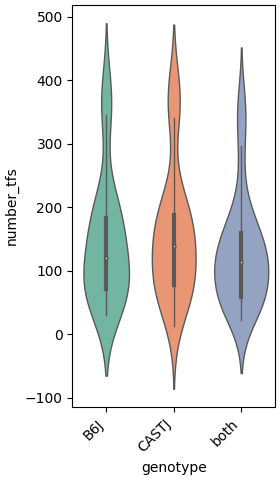

In [158]:
# Want a violin plot of with jitter
plt.figure(figsize=(3, 5))
sns.violinplot(
    data=grn_metadata_df,
    x="genotype",
    y="number_tfs",
    linewidth=1,
    palette="Set2",
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

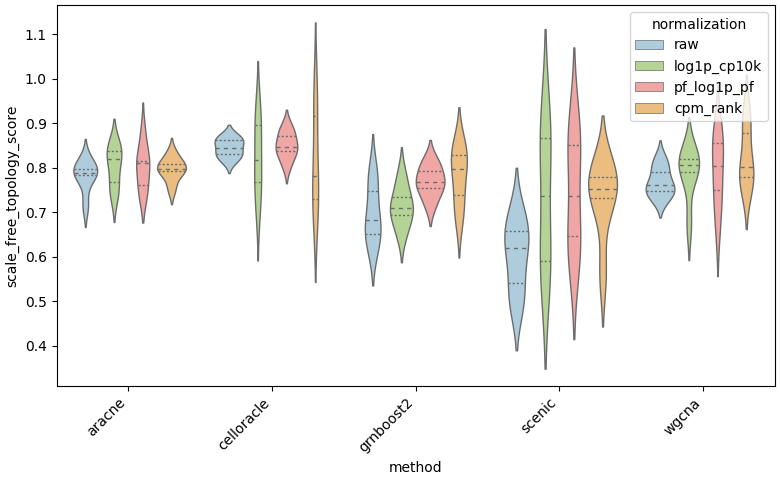

In [200]:
# Want a violin plot of with jitter, make normalizations as normalization_colors, make the box in the viprplot smaller
plt.figure(figsize=(8, 5))
sns.violinplot(
    data=grn_metadata_df,
    x="method",
    y="scale_free_topology_score",
    hue="normalization",
    linewidth=1,
    palette=normalization_colors,
    inner="quartile",

)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/cellar/users/aklie/projects/igvf/topic_grn_links/external/igvf_annual_meetings/2023/scale_free_topology_score_violin.pdf")

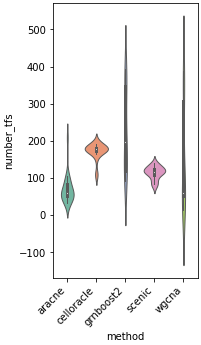

In [10]:
# Want a violin plot of with jitter
plt.figure(figsize=(3, 5))
sns.violinplot(
    data=grn_metadata_df,
    x="method",
    y="number_tfs",
    linewidth=1,
    palette="Set2",
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

/cellar/users/aklie/opt/miniconda3/envs/scverse-lite-py38/lib/python3.8/site-packages/seaborn/axisgrid.py:88: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 360x360 with 0 Axes>

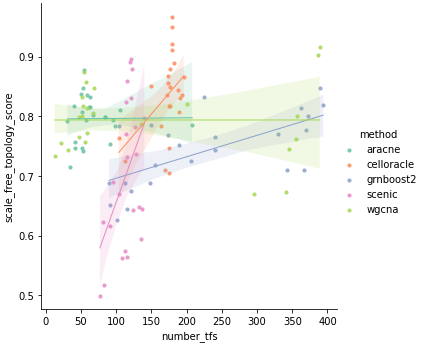

In [11]:
# lmplot with linear fits for each method of number_tfs vs scale_free_topology_score
plt.figure(figsize=(5, 5))
g = sns.lmplot(
    data=grn_metadata_df,
    x="number_tfs",
    y="scale_free_topology_score",
    hue="method",
    palette="Set2",
    scatter_kws={"s": 10},
    line_kws={"lw": 1},
)

## TF network score heatmap

In [12]:
# Let's start with just the both genotypes
grn_metadata_df = grn_metadata_df[grn_metadata_df["genotype"] == "both"]

In [13]:
# Create row annotation dataframe
df_rows = grn_metadata_df[["method", "dataset", "normalization", "genotype"]]
df_bar_tfs = grn_metadata_df[["number_tfs"]]
df_bar_connectivity = grn_metadata_df[["median_connectivity"]]
df_scatter = grn_metadata_df[["scale_free_topology_score"]]

In [14]:
# Create col annotation dataframe
df_cols = tf_metadata_df[["in_literature", "in_igvf_b01_LeftCortex"]].replace({True: "Yes", False: "No"})
df_bar = tf_metadata_df[["number_grns"]]

In [15]:
# Get a wide format dataframe based on the plot metric
plot_metric = "eigenvector_centrality"
df_heatmap = tf_scores_df.pivot_table(index="grn_name", columns="tf_name", values=plot_metric).fillna(0)

# Keep only GRNs that are in the metadata
df_heatmap = df_heatmap[df_heatmap.index.isin(grn_metadata_df.index)]

# Order by tf metadata
df_heatmap = df_heatmap[tf_metadata_df.index]

Starting plotting HeatmapAnnotations


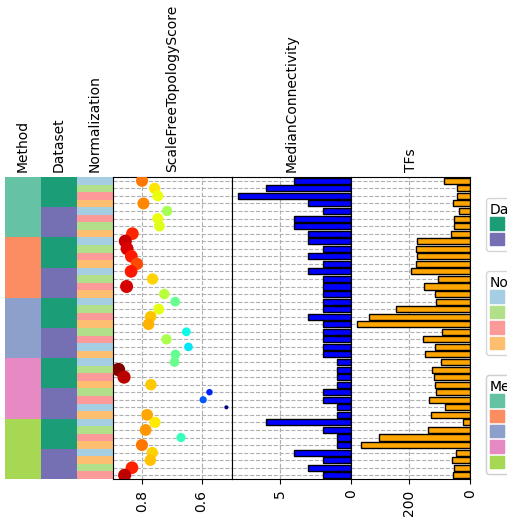

In [196]:
# Column annotations
row_ha = HeatmapAnnotation(
    Method=anno_simple(df_rows.method, legend=True, colors=method_colors),
    Dataset=anno_simple(df_rows.dataset, legend=True, colors=dataset_colors),
    Normalization=anno_simple(df_rows.normalization, legend=True, colors=normalization_colors),
    ScaleFreeTopologyScore=anno_scatterplot(df_scatter, legend=False),
    MedianConnectivity=anno_barplot(df_bar_connectivity, legend=False, colors="blue"),
    TFs=anno_barplot(df_bar_tfs, legend=False, colors="orange"),
    axis=0,
    plot=True,
)

In [151]:
# Row annotations
col_ha = HeatmapAnnotation(
    LiteratureTF=anno_simple(df_cols.in_literature, legend=True, colors=literature_colors),
    NumGRNs=anno_barplot(df_bar, legend=False),
    axis=1,
    plot=False
)

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/cellar/users/aklie/opt/miniconda3/envs/scverse-lite-py38/lib/python3.8/site-packages/PyComplexHeatmap/clustermap.py:803: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..


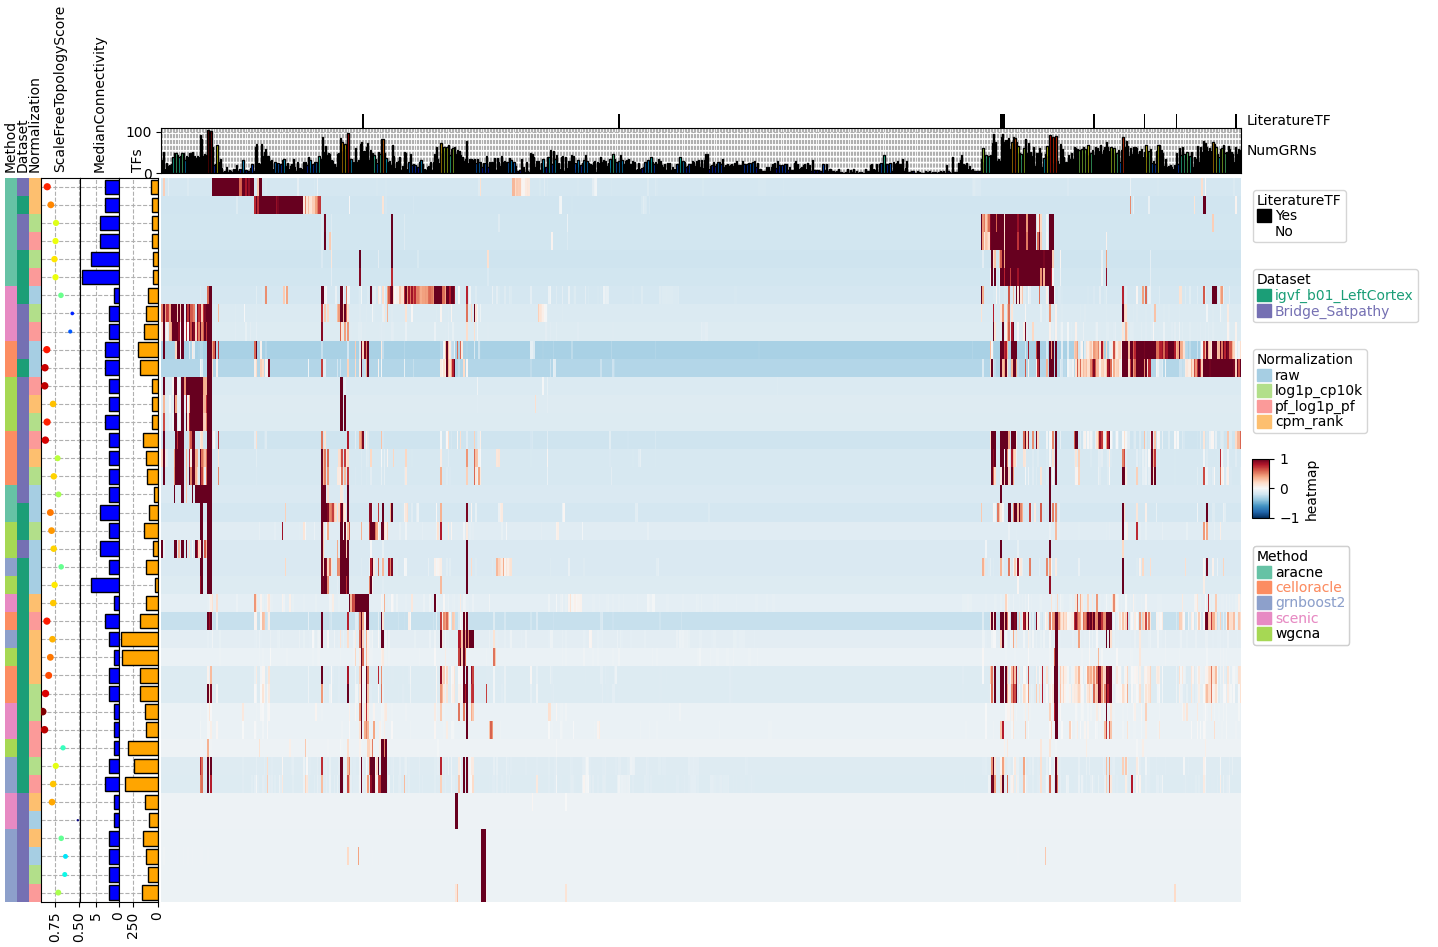

In [152]:
# Plot the heatmap
plt.figure(figsize=(16, 9))
cm = ClusterMapPlotter(
    data=df_heatmap,
    row_cluster=True,
    col_cluster=True,
    left_annotation=row_ha,
    top_annotation=col_ha,
    cmap="RdBu_r",
    z_score=0,
    vmin=-1,
    vmax=1,
)
plt.savefig("/cellar/users/aklie/projects/igvf/topic_grn_links/external/igvf_annual_meetings/2023/grn_heatmap_v2.pdf")

# Look at TF rankings across methods for microglia TFs

In [161]:
# Grab a list of the tfs in the literature
lit_tfs = tf_metadata_df[tf_metadata_df["in_literature"]].index

In [162]:
# Grab scores for only the tfs in the literature
lit_tf_scores_df = tf_scores_df[tf_scores_df["tf_name"].isin(lit_tfs)]

In [163]:
# Add in the metadata for plotting
lit_tf_plot_df = lit_tf_scores_df.merge(grn_metadata_df, left_on="grn_name", right_index=True)
lit_tf_plot_df

,tf_name,degree_all,degree_centrality_all,degree_in,degree_centrality_in,degree_out,degree_centrality_out,betweenness_centrality,eigenvector_centrality,grn_name,...,median_connectivity,max_connectivity,number_tfs,filtered_links_path,degree_centrality_out_path,eigenvector_centrality_path,betweenness_centrality_path,ulm_path,viper_path,aucell_path
3542,Sall1,2,0.005222,1,0.002611,1,0.002611,0.0,2.322047e-02,igvf_b01_LeftCortex_aracne_balanced_genotype_m...,...,5.0,128.0,50,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...
11225,Mef2a,51,0.133159,3,0.007833,48,0.125326,206.0,3.096954e-01,igvf_b01_LeftCortex_aracne_balanced_genotype_m...,...,5.0,128.0,50,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...
13775,Mef2c,36,0.093995,2,0.005222,34,0.088773,70.0,1.815109e-01,igvf_b01_LeftCortex_aracne_balanced_genotype_m...,...,5.0,128.0,50,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...
17968,Runx1,1,0.002611,1,0.002611,0,0.000000,0.0,4.460838e-03,igvf_b01_LeftCortex_aracne_balanced_genotype_m...,...,5.0,128.0,50,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...
3543,Sall1,1,0.002674,0,0.000000,1,0.002674,0.0,7.166523e-04,igvf_b01_LeftCortex_aracne_balanced_genotype_m...,...,5.0,135.0,59,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13828,Mef2c,147,0.164614,6,0.006719,141,0.157895,2455.0,7.645583e-17,Bridge_Satpathy_grnboost2_balanced_genotype_mi...,...,2.0,487.0,101,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...
13847,Mef2c,2,0.005013,0,0.000000,2,0.005013,0.0,1.840506e-03,igvf_b01_LeftCortex_wgcna_balanced_genotype_mi...,...,5.0,303.0,32,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users/aklie/projects/igvf/topic_grn_li...
13856,Mef2c,141,0.293750,2,0.004167,139,0.289583,109.0,5.018973e-01,Bridge_Satpathy_wgcna_balanced_genotype_microg...,...,3.0,351.0,53,/cellar/users/aklie/projects/igvf/topic_grn_li...,/cellar/users

## Plot based on GRN node scores

In [164]:
# Get orders for plotting
order = lit_tf_plot_df.groupby("tf_name").mean().sort_values(by=plot_metric, ascending=False).index
hue_order = lit_tf_plot_df.groupby("method").mean().sort_values(by=plot_metric, ascending=False).index

(0.0, 129.451875)

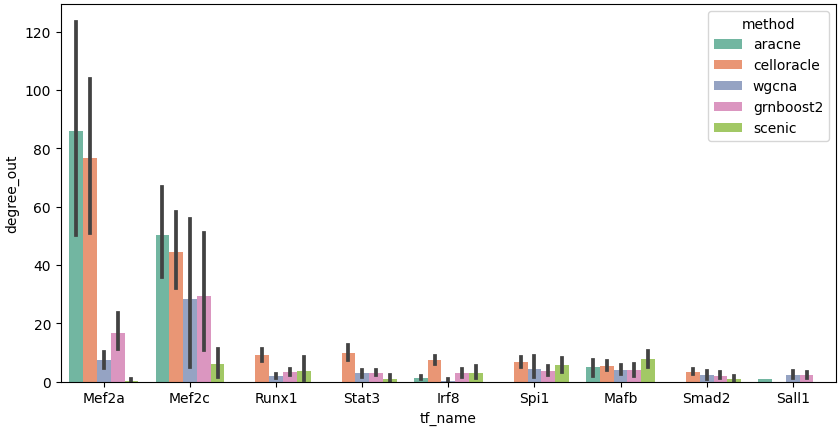

In [166]:
# Want a violin plot of eigenvector_centrality for each TF colored by method
plt.figure(figsize=(10, 5))
sns.barplot(
    data=lit_tf_plot_df,
    x="tf_name",
    y="degree_out",
    hue="method",
    linewidth=1,
    palette="Set2",
    order=order,
    hue_order=hue_order,
)
# Set min at 0
plt.ylim(bottom=0)

## Rankings from GRNs

In [167]:
rankings = ["aucell", "betweenness_centrality", "eigenvector_centrality", "degree_centrality_out", "ulm"]
lit_tf_ranking_plot_df = lit_tf_plot_df.set_index(["tf_name", "grn_name"])
for ranking in rankings:
    rank_list = []
    for i, ((tf_name, grn_name), row) in enumerate(lit_tf_ranking_plot_df.iterrows()):
        df =  pd.read_csv(row[f"{ranking}_path"], sep="\t", index_col=0)
        if tf_name in df.index:
            rank_list.append(df.loc[tf_name, "rank"]/len(df))
        else:
            rank_list.append(np.nan)
    lit_tf_ranking_plot_df[f"{ranking}_rank"] = rank_list
lit_tf_ranking_plot_df = lit_tf_ranking_plot_df.reset_index()

In [168]:
# Add in the best rank across
lit_tf_ranking_plot_df["best_rank"] = lit_tf_ranking_plot_df[[ranking + "_rank" for ranking in rankings]].min(axis=1)
lit_tf_ranking_plot_df["avg_rank"] = lit_tf_ranking_plot_df[[ranking + "_rank" for ranking in rankings]].mean(axis=1)

In [169]:
# Get orders for plotting
order = lit_tf_ranking_plot_df.groupby("tf_name").median().sort_values(by="best_rank").index
hue_order = lit_tf_ranking_plot_df.groupby("method").median().sort_values(by="best_rank").index

<Axes: xlabel='tf_name', ylabel='best_rank'>

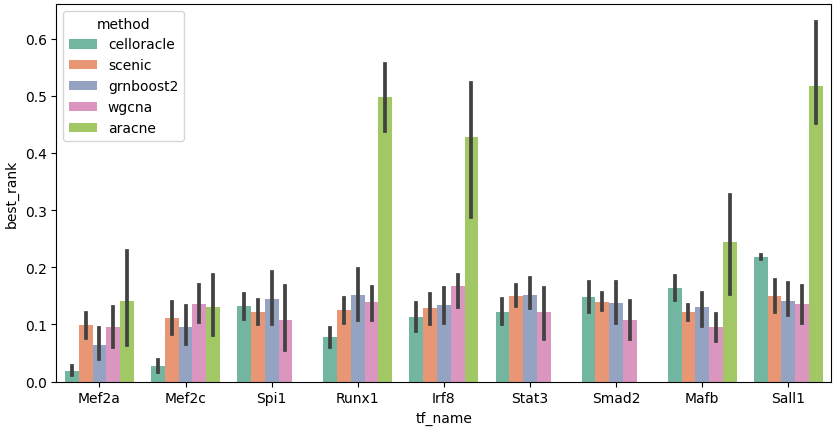

In [170]:
# Want a violin plot of eigenvector_centrality for each TF colored by method
plt.figure(figsize=(10, 5))
sns.barplot(
    data=lit_tf_ranking_plot_df,
    x="tf_name",
    y="best_rank",
    hue="method",
    linewidth=1,
    palette=method_colors,
    order=order,
    hue_order=hue_order,
)

## Load in baselines

In [171]:
# Read in the metadata
baseline_metadata_df = pd.read_csv(os.path.join(results_dir, dataset_name, in_date, "cleaned_baseline_metadata.tsv"), sep="\t", index_col=0)
len(baseline_metadata_df)

24

In [172]:
# Keep only "both" genotype
baseline_metadata_df = baseline_metadata_df[baseline_metadata_df["genotype"] == "both"]

In [173]:
# Get baseline rankings
rankings = ["expression", "ulm", "viper", "aucell"]
ranks = {}
lit_tf_ranking_baseline_tf = pd.DataFrame(index=lit_tfs, columns=[ranking + "_rank" for ranking in rankings])
for ranking in rankings:
    ranks[f"{ranking}_rank"] = {}
    for i, (grn_name, row) in enumerate(baseline_metadata_df.iterrows()):
        df =  pd.read_csv(row[f"{ranking}_path"], sep="\t", index_col=0)
        ranks[f"{ranking}_rank"][grn_name] = {}
        for tf_name in lit_tfs:
            if tf_name in df.index:
                ranks[f"{ranking}_rank"][grn_name][tf_name] = df.loc[tf_name, "rank"]/len(df)
            else:
                ranks[f"{ranking}_rank"][grn_name][tf_name] = np.nan

In [174]:
# Pull out expression ranks
expression_df = pd.DataFrame(ranks["expression_rank"])
expression_df = expression_df.melt(value_name="best_rank", var_name="grn_name", ignore_index=False).reset_index()
expression_df["tf_name"] = expression_df["index"]
expression_df["method"] = "expression"
expression_df.drop(columns=["index"], inplace=True)

In [175]:
# Pull out dorothea ulm ranks
ulm_df = pd.DataFrame(ranks["ulm_rank"])
ulm_df = ulm_df.melt(value_name="best_rank", var_name="grn_name", ignore_index=False).reset_index()
ulm_df["tf_name"] = ulm_df["index"]
ulm_df["method"] = "dorothea_ulm"
ulm_df.drop(columns=["index"], inplace=True)

In [183]:
# Add to the dataframe
lit_tf_ranking_plot_df = pd.concat([lit_tf_ranking_plot_df, expression_df, ulm_df])
lit_tf_ranking_plot_df["best_rank"] = 1 - lit_tf_ranking_plot_df["best_rank"]

In [177]:
# Get orders for plotting
order = lit_tf_ranking_plot_df.groupby("tf_name").median().sort_values(by="best_rank").index
hue_order = lit_tf_ranking_plot_df.groupby("method").median().sort_values(by="best_rank").index

In [184]:
hue_order = ['celloracle', 'wgcna', 'grnboost2', 'scenic', 'aracne', 'dorothea_ulm', 'expression']

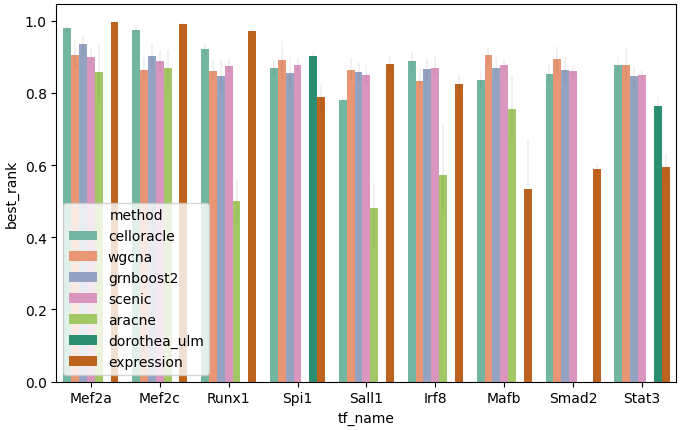

In [202]:
# Want a violin plot of eigenvector_centrality for each TF colored by method, with no error bars, add some
plt.figure(figsize=(8, 5))
sns.barplot(
    data=lit_tf_ranking_plot_df,
    x="tf_name",
    y="best_rank",
    hue="method",
    linewidth=1,
    palette=method_colors + sns.color_palette("Dark2").as_hex()[:2],
    order=order,
    hue_order=hue_order,
    errwidth=0.1,
)
# Set min at 0
plt.ylim(bottom=0)

plt.savefig("/cellar/users/aklie/projects/igvf/topic_grn_links/external/igvf_annual_meetings/2023/tf_ranking.pdf")

# DONE!

---

# Scratch